Found 1633 images belonging to 2 classes.
Found 408 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (1, 3, 3, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 3, 3, 1280)        │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 3, 3, 512)         │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 512)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 2)                 │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,050,818 (11.64 MB)

 Trainable params: 790,274 (3.01 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20


/Users/hasithapramuditha/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 0.5507 - loss: 10.5898 - val_accuracy: 0.5294 - val_loss: 3.6033 - learning_rate: 1.0000
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 232ms/step - accuracy: 0.5896 - loss: 2.0245 - val_accuracy: 0.5221 - val_loss: 1.2834 - learning_rate: 1.0000
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - accuracy: 0.6273 - loss: 1.1231 - val_accuracy: 0.5000 - val_loss: 1.1376 - learning_rate: 1.0000
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step - accuracy: 0.6824 - loss: 0.8533 - val_accuracy: 0.5172 - val_loss: 1.0166 - learning_rate: 0.5000
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.6706 - loss: 0.9425 - val_accuracy: 0.5368 - val_loss: 1.0833 - learning_rate: 0.5000
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - accuracy: 0.7336 - loss: 0.6984 - val_accuracy: 0.5270 - val_loss: 0.9617 - learning_rate: 0.1000
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 255ms/step - accuracy: 0.7480 - loss: 0.6817 - val

/var/folders/jj/k5cpdpls3qj5fpnjrrjhldlr0000gn/T/ipykernel_22668/672648854.py:140: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


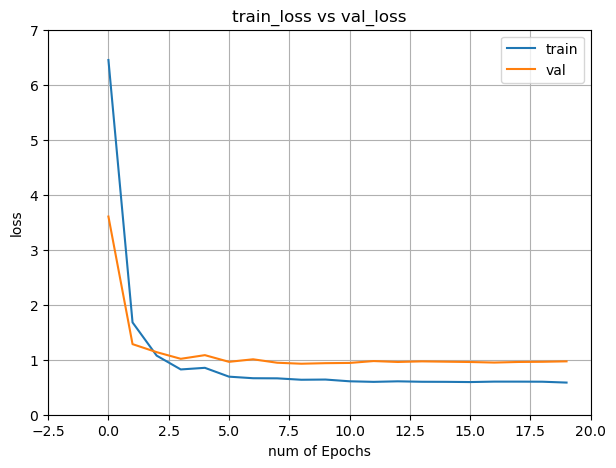

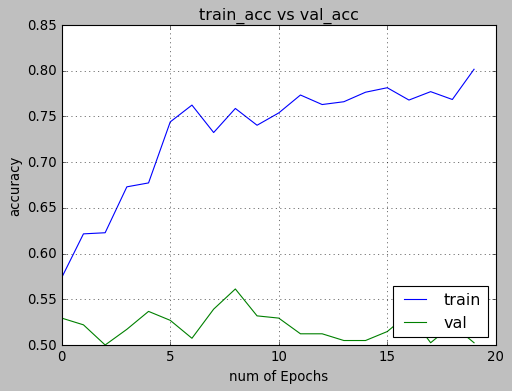

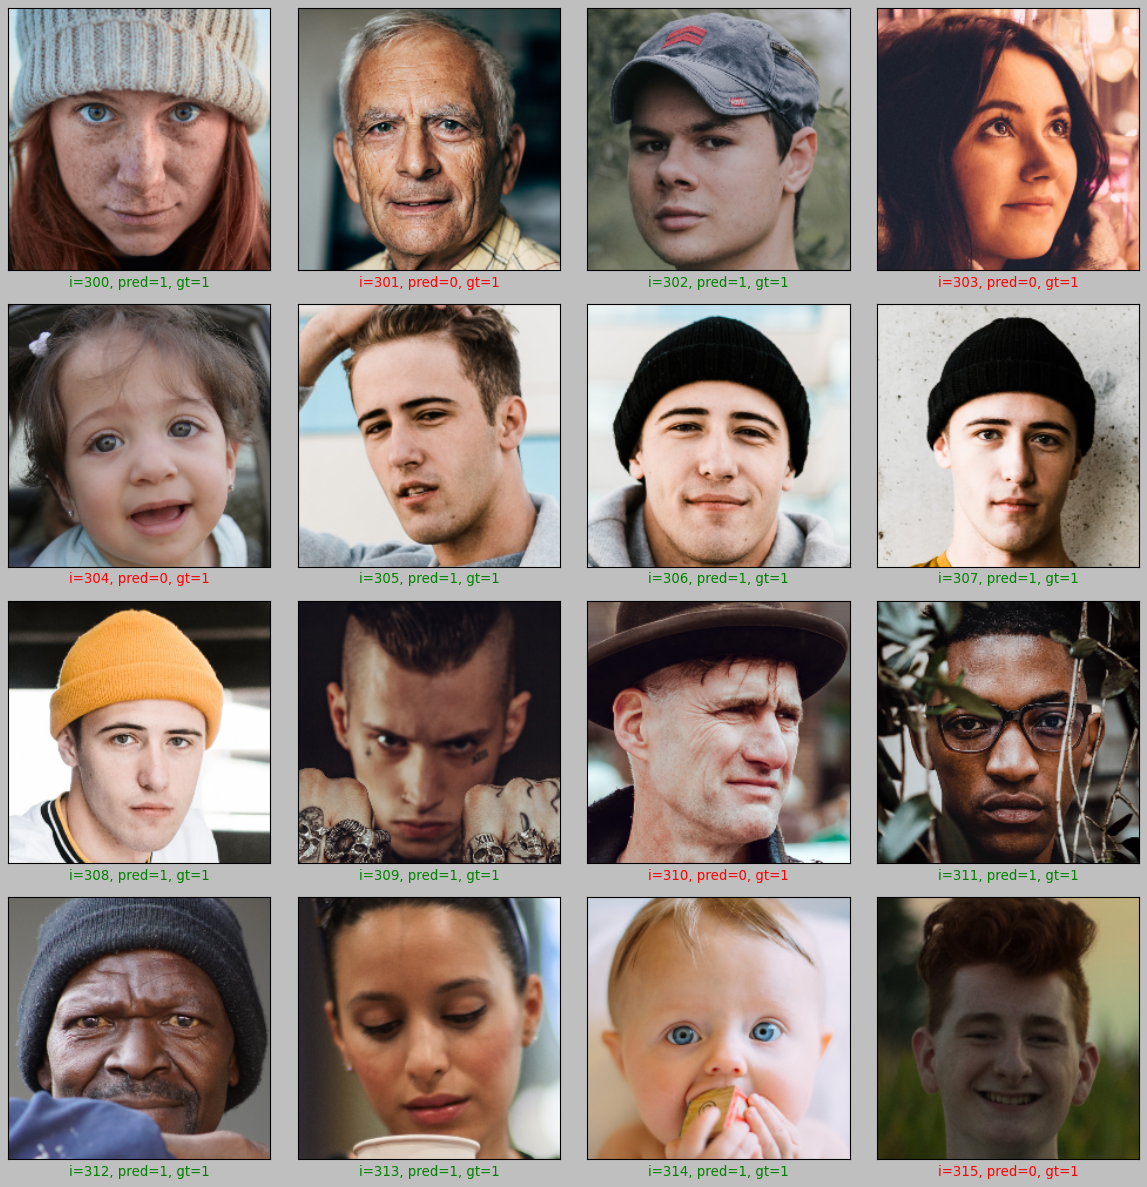

In [1]:
import numpy as np
import pandas as pd
from keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense,BatchNormalization, Flatten, MaxPool2D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.regularizers import l2

def load_img(path):
    image = cv2.imread(path)
    image = cv2.resize(image,(224, 224))
    return image[...,::-1]

dataset_path = "Real and Fake Face Detection Dataset"
data_with_aug = ImageDataGenerator(horizontal_flip=True,
                                   vertical_flip=False,
                                   rescale=1./255,
                                  validation_split=0.2)
train = data_with_aug.flow_from_directory(dataset_path,
                                          class_mode="binary",
                                          target_size=(96, 96),
                                          batch_size=32,
                                          subset="training")
val = data_with_aug.flow_from_directory(dataset_path,
                                          class_mode="binary",
                                          target_size=(96, 96),
                                          batch_size=32,
                                          subset="validation"
                                          )
mnet = MobileNetV2(include_top = False, weights = "imagenet" ,input_shape=(96,96,3))
from keras.optimizers import SGD, RMSprop
opt = SGD(learning_rate=0.01) 
tf.keras.backend.clear_session()
l2_reg = 0.01
model = Sequential([mnet,
            BatchNormalization(),
            Dense(512, activation = "relu",kernel_regularizer=l2(l2_reg)),
            GlobalAveragePooling2D(),
            
            Dense(256, activation = "sigmoid",kernel_regularizer=l2(l2_reg)),
            
            Dropout(0.5),

            #Dense(128, activation = "relu",kernel_regularizer=l2(l2_reg)),
            #Dropout(0.3),

            Dense(2, activation = "softmax")])

model.layers[0].trainable = False

input_shape = (1, 96, 96, 3)
model.build(input_shape)

model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

model.summary()
def scheduler(epoch):
    if epoch <= 2:
        return 1.0
    elif epoch > 2 and epoch <= 4:
        return 0.5
    elif epoch > 4 and epoch <= 9:
        return 0.1 
    elif epoch > 9 and epoch <= 14:
        return 0.01 
    else:
        return 0.001

lr_callbacks = tf.keras.callbacks.LearningRateScheduler(scheduler)
hist = model.fit(train,
                 epochs=20,
                 callbacks=[lr_callbacks],
                 validation_data=val)  
epochs = 20
train_loss = hist.history['loss']
val_loss = hist.history['val_loss']
train_acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
xc = range(epochs)

plt.figure(1,figsize=(7,5))
plt.plot(xc,train_loss)
plt.plot(xc,val_loss)
plt.xlabel('num of Epochs')
plt.ylabel('loss')
plt.title('train_loss vs val_loss')
plt.grid(True)
plt.legend(['train','val'])

plt.style.use(['classic'])

plt.figure(2,figsize=(7,5))
plt.plot(xc,train_acc)
plt.plot(xc,val_acc)
plt.xlabel('num of Epochs')
plt.ylabel('accuracy')
plt.title('train_acc vs val_acc')
plt.grid(True)
plt.legend(['train','val'],loc=4)

plt.style.use(['classic'])

predictions = model.predict(val)
val_path = "Real and Fake Face Detection Dataset/"

plt.figure(figsize=(15,15))

start_index = 300

for i in range(16):
  plt.subplot(4,4, i+1)
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  
  preds = np.argmax(predictions[[start_index+i]])
    
  gt = val.filenames[start_index+i][9:13]

  
  if gt == "fake":
    gt = 0
  else:
    gt = 1
    
  if preds != gt:
    col ="r"
  else:
    col = "g"

  plt.xlabel('i={}, pred={}, gt={}'.format(start_index+i,preds,gt),color=col)
  plt.imshow(load_img(val_path+val.filenames[start_index+i]))
  plt.tight_layout()

plt.show()

In [2]:
# Assuming `new_image_path` is the path to the new photo you want to predict
new_image_path = "b.jpg"

# Load and preprocess the new image
new_image = load_img(new_image_path)
new_image = cv2.resize(new_image, (96, 96))
new_image = new_image.astype(np.float32) / 255.0  # Normalize pixel values

# Reshape the image to match the input shape of the model
new_image = np.expand_dims(new_image, axis=0)  # Add batch dimension

# Make predictions using the model
predictions = model.predict(new_image)

# Get the predicted class (0 for fake, 1 for real)
predicted_class = np.argmax(predictions)

# Print the predicted class
if predicted_class == 0:
    print("Predicted class: Fake")
else:
    print("Predicted class: Real")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
Predicted class: Real


In [3]:
# Assuming `new_image_path` is the path to the new photo you want to predict
new_image_path = "h.jpg"

# Load and preprocess the new image
new_image = load_img(new_image_path)
new_image = cv2.resize(new_image, (96, 96))
new_image = new_image.astype(np.float32) / 255.0  # Normalize pixel values

# Reshape the image to match the input shape of the model
new_image = np.expand_dims(new_image, axis=0)  # Add batch dimension

# Make predictions using the model
predictions = model.predict(new_image)

# Get the predicted class (0 for fake, 1 for real)
predicted_class = np.argmax(predictions)

# Print the predicted class
if predicted_class == 0:
    print("Predicted class: Fake")
else:
    print("Predicted class: Real")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted class: Fake
